<a href="https://colab.research.google.com/github/Sapkina/face_recognition/blob/main/Detector_class_regress_RESULT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

import os
import numpy as np
import csv
import matplotlib.pyplot as plt

# Данные

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/final_dataset_detector/images'
annotations_path = '/content/drive/MyDrive/final_dataset_detector/annotations.csv'

## Разделение на train/validation/test

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Загружаем аннотации из CSV
annotations_df = pd.read_csv(annotations_path)

# Получаем список уникальных изображений
image_ids = annotations_df["image_id"].unique()

# Разбиваем на train (80%), test (10%), val (10%)
train_ids, test_ids = train_test_split(image_ids, test_size=0.2, random_state=42)
val_ids, test_ids = train_test_split(test_ids, test_size=0.5, random_state=42)

print(f"Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")

Train: 28030, Val: 3504, Test: 3504


# Dataset

In [ ]:
class DetectionDataset(Dataset):
    def __init__(self, annotations_file, images_dir, image_ids, transform=None):
        self.annotations_csv = annotations_file
        self.images_dir = images_dir
        self.image_ids = set(image_ids)  # Ограничиваем датасет только этими изображениями
        self.transform = transform

        # Загружаем аннотации из CSV
        self.image_annotations = self.load_annotations()

    def load_annotations(self):
        annotations = {}
        with open(self.annotations_csv, "r") as file:
            reader = csv.reader(file)
            next(reader)  # Пропускаем заголовок
            for row in reader:
                image_id = row[0]
                if image_id not in self.image_ids:  # Добавляем только те, что в разбиении
                    continue
                x_min, y_min, width, height = map(int, row[1:5])
                class_id = int(row[5])

                if image_id not in annotations:
                    annotations[image_id] = []
                annotations[image_id].append([x_min, y_min, x_min + width, y_min + height, class_id])
        return annotations

    def __len__(self):
        return len(self.image_annotations)

    def __getitem__(self, idx):
        image_id = list(self.image_annotations.keys())[idx]
        image_path = os.path.join(self.images_dir, image_id)

        try:
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            return None

        annotations = self.image_annotations[image_id]
        labels = np.array([ann[4] for ann in annotations])
        bboxes = [ann[:4] for ann in annotations]

        bboxes = np.array(bboxes, dtype=np.float32)

        # Убираем "пустые" боксы
        valid_indices = ~(np.all(bboxes == 0, axis=1))
        if np.any(valid_indices):
            bboxes = bboxes[valid_indices]
            labels = labels[valid_indices]
        else:
            bboxes = np.array([[0, 0, 1, 1]], dtype=np.float32)
            labels = np.array([0])

        # Применяем аугментации (на абсолютных координатах)
        if self.transform:
            augmented = self.transform(image=image, bboxes=bboxes, labels=labels)
            image = augmented['image']
            bboxes = np.array(augmented['bboxes'], dtype=np.float32)
            labels = torch.tensor(augmented['labels'], dtype=torch.long)

        # Теперь нормализуем bbox: после Resize → финальный размер точно 224x224
        bboxes[:, [0, 2]] /= 224
        bboxes[:, [1, 3]] /= 224
        bboxes = torch.tensor(bboxes, dtype=torch.float32)

        return image, bboxes, labels

In [ ]:
train_transform = A.Compose([
    A.RandomScale(scale_limit=0.1, p=0.3),  # Масштабирование
    A.HorizontalFlip(p=0.5),  # Отражение 50% изображений
    A.RandomBrightnessContrast(p=0.2),  # Изменение яркости и контраста
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # Размытие с 20% вероятностью
    A.Resize(height=224, width=224),  # **Обязательно фиксируем размер после всех изменений**
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['labels'],
                            check_each_transform=True, min_visibility=0.1))


test_transform = A.Compose([
    A.Resize(height=224, width=224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Модель

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

In [ ]:
class FaceDetectionModel(nn.Module):
    def __init__(self):
        super(FaceDetectionModel, self).__init__()

        # Загружаем MobileNetV3-Large (без последнего слоя)
        backbone = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        self.feature_extractor = backbone.features  # Берем только сверточную часть

        # Регрессия (bounding box)
        self.regression_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Усреднение по пространству
            nn.Flatten(),
            nn.Linear(960, 512),  # MobileNetV3 имеет 960 выходных каналов
            nn.BatchNorm1d(512),  # BatchNorm стабилизирует градиенты
            nn.ReLU(),
            nn.Dropout(0.2),  # Dropout для регуляризации
            nn.Linear(512, 4),  # 4 выхода - координаты бокса
            nn.Sigmoid()
        )

        # Классификация
        self.classifier_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Усреднение по пространству
            nn.Flatten(),
            nn.Linear(960, 512),  # MobileNetV3 имеет 960 выходных каналов
            nn.ReLU(),
            nn.Dropout(0.2),  # Dropout для регуляризации
            nn.Linear(512, 1)  # Один выход для бинарной классификации (например, присутствие лица)
        )

    def forward(self, x):
        features = self.feature_extractor(x)  # Пропускаем через backbone

        # Получаем координаты бокса (регрессия)
        bbox = self.regression_head(features)

        # Получаем предсказания для классификации
        classification = self.classifier_head(features)

        return classification, bbox  # Возвращаем оба предсказания

## Функции потерь и метрики

In [ ]:
# Функция потерь для классификации
def loss_fn_classification(preds_class, targets_class):
    return nn.BCEWithLogitsLoss()(preds_class.squeeze(1), targets_class.float())

# Итоговая функция потерь с учетом классов
def total_loss_fn(preds_class, targets_class, preds_bbox, targets_bbox, alpha=0.3, beta=5):
    # Маска: выбираем только примеры, где класс НЕ 0 (то есть, где есть человек)
    valid_bboxes_mask = (targets_class > 0)

    # Потери для классификации считаем для всех примеров
    class_loss = loss_fn_classification(preds_class, targets_class)

    # Потери для регрессии только для валидных боксов
    if valid_bboxes_mask.any():
        bbox_loss = giou_loss(preds_bbox[valid_bboxes_mask], targets_bbox[valid_bboxes_mask])
    else:
        bbox_loss = torch.tensor(0.0, device=preds_bbox.device)  # Если нет валидных боксов, ставим 0

    # Общая функция потерь
    total_loss = alpha * class_loss + beta * bbox_loss
    return total_loss

In [ ]:
def intersection_over_union(preds_bbox, target_bbox):
    """
    Функция для вычисления IoU между предсказанными и истинными боксов.

    Parameters:
    preds_bbox (torch.Tensor): Тензор с предсказанными боксами (batch_size x 4)
    target_bbox (torch.Tensor): Тензор с истинными боксами (batch_size x 4)

    Returns:
    torch.Tensor: Тензор с IoU для каждого примера в батче.
    """
    # Преобразуем координаты в (x1, y1, x2, y2)
    x1_pred, y1_pred, x2_pred, y2_pred = preds_bbox.split(1, dim=-1)
    x1_true, y1_true, x2_true, y2_true = target_bbox.split(1, dim=-1)

    # Вычисляем координаты пересечения
    x1_inter = torch.max(x1_pred, x1_true)
    y1_inter = torch.max(y1_pred, y1_true)
    x2_inter = torch.min(x2_pred, x2_true)
    y2_inter = torch.min(y2_pred, y2_true)

    # Вычисляем площадь пересечения
    inter_area = torch.clamp(x2_inter - x1_inter, min=0) * torch.clamp(y2_inter - y1_inter, min=0)

    # Вычисляем площадь каждого бокса
    pred_area = (x2_pred - x1_pred) * (y2_pred - y1_pred)
    true_area = (x2_true - x1_true) * (y2_true - y1_true)

    # Вычисляем объединенную площадь
    union_area = pred_area + true_area - inter_area

    # Вычисляем IoU
    iou = inter_area / torch.clamp(union_area, min=1e-6)  # добавляем маленькое значение для предотвращения деления на 0
    return iou

In [ ]:
def giou_loss(preds, targets):
    # Convert [x_min, y_min, x_max, y_max] to [x1, y1, x2, y2]
    x1 = torch.min(preds[:, 0], preds[:, 2])
    y1 = torch.min(preds[:, 1], preds[:, 3])
    x2 = torch.max(preds[:, 0], preds[:, 2])
    y2 = torch.max(preds[:, 1], preds[:, 3])
    pred_boxes = torch.stack([x1, y1, x2, y2], dim=1)

    x1g = torch.min(targets[:, 0], targets[:, 2])
    y1g = torch.min(targets[:, 1], targets[:, 3])
    x2g = torch.max(targets[:, 0], targets[:, 2])
    y2g = torch.max(targets[:, 1], targets[:, 3])
    target_boxes = torch.stack([x1g, y1g, x2g, y2g], dim=1)

    # Intersection
    xi1 = torch.max(pred_boxes[:, 0], target_boxes[:, 0])
    yi1 = torch.max(pred_boxes[:, 1], target_boxes[:, 1])
    xi2 = torch.min(pred_boxes[:, 2], target_boxes[:, 2])
    yi2 = torch.min(pred_boxes[:, 3], target_boxes[:, 3])
    inter_area = torch.clamp((xi2 - xi1), min=0) * torch.clamp((yi2 - yi1), min=0)

    # Union
    box_area = (pred_boxes[:, 2] - pred_boxes[:, 0]) * (pred_boxes[:, 3] - pred_boxes[:, 1])
    target_area = (target_boxes[:, 2] - target_boxes[:, 0]) * (target_boxes[:, 3] - target_boxes[:, 1])
    union_area = box_area + target_area - inter_area

    # IoU
    iou = inter_area / (union_area + 1e-6)

    # Enclosing box
    xc1 = torch.min(pred_boxes[:, 0], target_boxes[:, 0])
    yc1 = torch.min(pred_boxes[:, 1], target_boxes[:, 1])
    xc2 = torch.max(pred_boxes[:, 2], target_boxes[:, 2])
    yc2 = torch.max(pred_boxes[:, 3], target_boxes[:, 3])
    enclose_area = (xc2 - xc1) * (yc2 - yc1)

    giou = iou - (enclose_area - union_area) / (enclose_area + 1e-6)
    return 1 - giou.mean()

# Подготовка DataLoader

In [ ]:
train_dataset = DetectionDataset(annotations_path, dataset_path, train_ids, transform=train_transform)
val_dataset = DetectionDataset(annotations_path, dataset_path, val_ids, transform=test_transform)
test_dataset = DetectionDataset(annotations_path, dataset_path, test_ids, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Посмотрим на данные

In [ ]:
def visualize_samples(dataset, num_samples=8, figsize=(20, 10)):
    length = len(dataset)
    indexes = np.random.choice(range(length), size=num_samples, replace=False)

    items = [dataset[index] for index in indexes]
    rows, cols = 2, num_samples // 2
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)

    for idx, item in enumerate(items):
        row, col = divmod(idx, cols)

        image, bboxes, label= item

        image_np = image.permute(1, 2, 0).numpy()
        img_h, img_w = image_np.shape[:2]
        normalized_image = np.clip((image_np - image_np.min()) / (image_np.max() - image_np.min()), 0, 1)

        # Умножаем нормализованные координаты на исходные размеры
        for bbox in bboxes:
            if len(bbox) == 4:
                x_min = int(bbox[0] * 224)
                y_min = int(bbox[1] * 224)
                x_max = int(bbox[2] * 224)
                y_max = int(bbox[3] * 224)

                # Приводим координаты к новому масштабу (если изображение уже стало 224x224)
                x_min = int(x_min * (img_w / 224))
                y_min = int(y_min * (img_h / 224))
                x_max = int(x_max * (img_w / 224))
                y_max = int(y_max * (img_h / 224))

                cv2.rectangle(normalized_image, (x_min, y_min), (x_max, y_max), color=(1, 0, 0), thickness=2)

        ax[row, col].imshow(normalized_image)
        ax[row, col].axis("off")

    plt.tight_layout()
    plt.show()

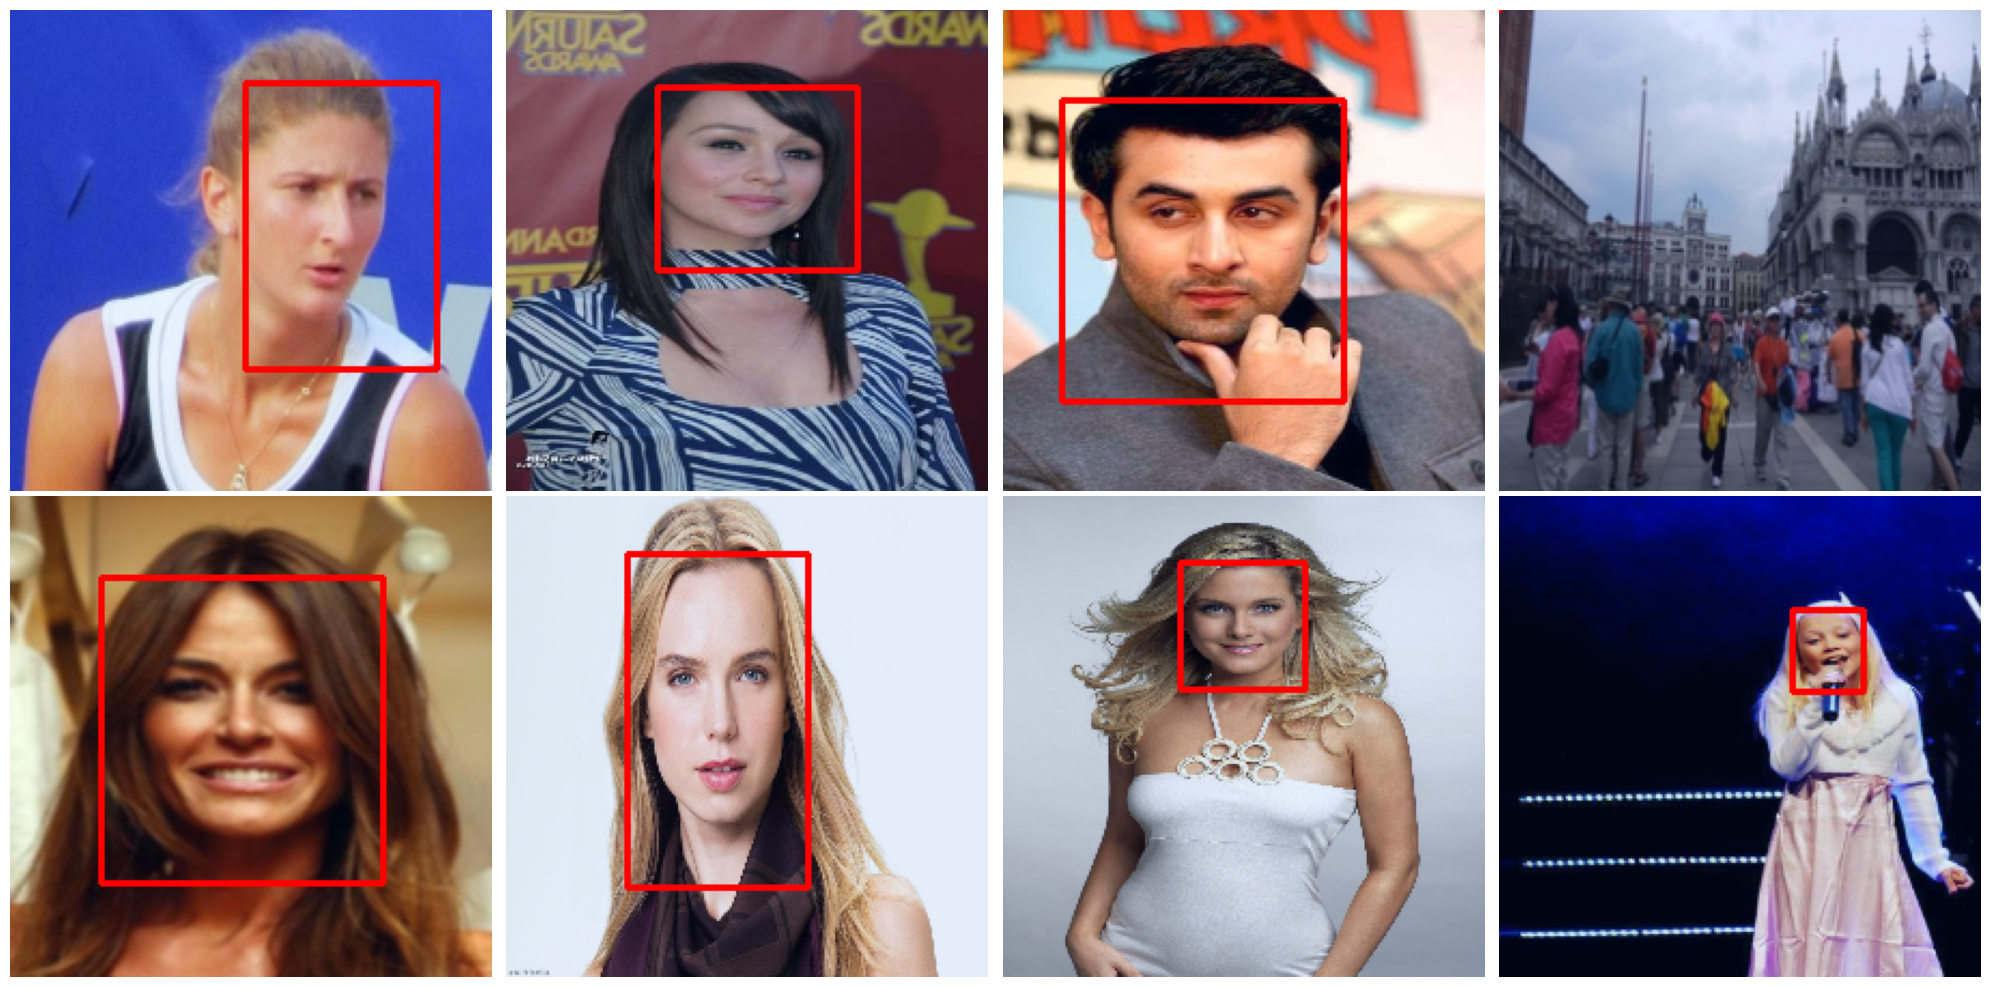

In [ ]:
visualize_samples(train_dataset)

# Обучение

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch.nn.functional as F

In [ ]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    iou_scores, all_preds, all_targets = [], [], []

    total_mse = 0
    total_smooth_l1 = 0
    count = 0

    for images, bboxes, labels in tqdm(dataloader, desc="Training"):
        images, bboxes, labels = images.to(device), bboxes.to(device), labels.to(device)

        # Убираем лишнее измерение, если есть
        bboxes = bboxes.squeeze(1)  # [batch, 4]
        labels = labels.squeeze(1)

        optimizer.zero_grad()
        preds_class, preds_bbox = model(images)

        # Основная loss-функция
        loss = total_loss_fn(preds_class, labels, preds_bbox, bboxes)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        count += bboxes.size(0)

        # Метрики регрессии
        total_mse += F.mse_loss(preds_bbox, bboxes, reduction='sum').item()
        total_smooth_l1 += F.smooth_l1_loss(preds_bbox, bboxes, reduction='sum').item()

        # IoU и метрики классификации
        iou_scores.append(intersection_over_union(preds_bbox, bboxes))
        all_preds.extend(torch.sigmoid(preds_class).detach().cpu().numpy() > 0.5)
        all_targets.extend(labels.detach().cpu().numpy())

    # Средние значения
    avg_iou = torch.cat(iou_scores).mean().item()
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)

    avg_mse = total_mse / count
    avg_smooth_l1 = total_smooth_l1 / count

    # Логируем в W&B
    wandb.log({
        "Train loss": total_loss / len(dataloader),
        "Train IoU": avg_iou,
        "Train Accuracy": accuracy,
        "Train Precision": precision,
        "Train Recall": recall,
        "Train F1-score": f1,
        "Train MSE": avg_mse,
        "Train SmoothL1": avg_smooth_l1,
    })

    return total_loss / len(dataloader)

## Оценка модели  

In [ ]:
import torch.nn.functional as F

def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    iou_scores, all_preds, all_targets = [], [], []

    total_mse = 0
    total_smooth_l1 = 0
    count = 0

    with torch.no_grad():
        for images, bboxes, labels in tqdm(dataloader, desc="Evaluating"):
            images, bboxes, labels = images.to(device), bboxes.to(device), labels.to(device)

            bboxes = bboxes.squeeze(1)
            labels = labels.squeeze(1)

            preds_class, preds_bbox = model(images)
            loss = total_loss_fn(preds_class, labels, preds_bbox, bboxes)
            total_loss += loss.item()
            count += bboxes.size(0)

            # Метрики регрессии
            total_mse += F.mse_loss(preds_bbox, bboxes, reduction='sum').item()
            total_smooth_l1 += F.smooth_l1_loss(preds_bbox, bboxes, reduction='sum').item()

            # Метрики классификации и IoU
            iou_scores.append(intersection_over_union(preds_bbox, bboxes))
            all_preds.extend(torch.sigmoid(preds_class).detach().cpu().numpy() > 0.5)
            all_targets.extend(labels.detach().cpu().numpy())

    avg_iou = torch.cat(iou_scores).mean().item()
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    avg_mse = total_mse / count
    avg_smooth_l1 = total_smooth_l1 / count

    wandb.log({
        "Val Loss": total_loss / len(dataloader),
        "Val IoU": avg_iou,
        "Val Accuracy": accuracy,
        "Val Precision": precision,
        "Val Recall": recall,
        "Val F1-score": f1,
        "Val MSE": avg_mse,
        "Val SmoothL1": avg_smooth_l1,
    })

    return total_loss / len(dataloader), avg_iou, avg_mse, avg_smooth_l1, accuracy, precision, recall, f1

## Основная функция обучения по всем эпохам

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, num_epochs, device):
  model.to(device)

  for epoch in range(1, num_epochs + 1):
    print(f"\nEpoch {epoch}/{num_epochs}")

    # Обучение
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    print(f"Train Loss: {train_loss:.4f}")

    # Валидация
    val_loss, avg_iou, mse, smooth, acc, prec, rec, f1 = evaluate(model, val_loader, device)
    print(f"Val Loss: {val_loss:.4f}, IoU: {avg_iou:.4f}, MSE: {mse:.4f}, SmoothL1: {smooth:.4f}")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

    save_model(model, optimizer, epoch, train_loss)

  wandb.finish()

## Для сохранения состояния модели

In [ ]:
def save_model(model, optimizer, epoch, loss, filename="model_checkpoint.pth"):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filename)
    print(f"Model checkpoint saved at epoch {epoch}")

def load_model(model, optimizer, filename="model_checkpoint.pth"):
    checkpoint = torch.load(filename)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    print(f"Model loaded from epoch {epoch} with loss {loss}")
    return model, optimizer, epoch, loss

# Запуск обучения

In [ ]:
from tqdm import tqdm
import wandb

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FaceDetectionModel()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 153MB/s]


In [ ]:
device

device(type='cuda')

In [ ]:
wandb.login(key='82d07644b33dce27e12b682550705a879df642e8')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: elenasapunovaaa (elenasapunovaaa-transbaikal-state-university-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(project='face_detector', name='Detector_20.04_run')

In [ ]:
# import random

# def get_subset(dataset, subset_size):
#     # Выбираем случайное подмножество из датасета
#     indices = random.sample(range(len(dataset)), subset_size)
#     subset = torch.utils.data.Subset(dataset, indices)
#     return subset

In [ ]:
# # Размер подмножества, например, 100 изображений
# subset_size = 50

# # Создаем подмножество данных для быстрого теста
# train_subset = get_subset(train_dataset, subset_size)
# val_subset = get_subset(val_dataset, subset_size)
# test_subset = get_subset(test_dataset, subset_size)

# # Создаем DataLoader'ы для подмножеств
# train_loader_subset = DataLoader(train_subset, batch_size=4, shuffle=True)
# val_loader_subset = DataLoader(val_subset, batch_size=4, shuffle=False)
# test_loader_subset = DataLoader(test_subset, batch_size=4, shuffle=False)

In [ ]:
train_model(model, train_loader, val_loader, optimizer, num_epochs=12, device=device)


Epoch 1/12


Training: 100%|██████████| 1752/1752 [3:03:33<00:00,  6.29s/it]


Train Loss: 2.0118


Evaluating: 100%|██████████| 219/219 [21:55<00:00,  6.01s/it]


Val Loss: 3.9988, IoU: 0.0000, MSE: 5.1215, SmoothL1: 1.4533
Accuracy: 0.9949, Precision: 0.9992, Recall: 0.9935, F1: 0.9963
Model checkpoint saved at epoch 1

Epoch 2/12


...

Train Loss: 0.8740


Evaluating: 100%|██████████| 219/219 [00:35<00:00,  6.16it/s]


Val Loss: 4.0048, IoU: 0.0000, MSE: 5.3202, SmoothL1: 1.5575
Accuracy: 0.9966, Precision: 0.9992, Recall: 0.9959, F1: 0.9976
Model checkpoint saved at epoch 7

Epoch 8/12


Training:  77%|███████▋  | 1353/1752 [05:53<01:44,  3.82it/s]


KeyboardInterrupt: 

# Проверка на тесте

In [ ]:
evaluate(model, test_loader, device)

In [ ]:
torch.save(model.state_dict(), "detector_weights.pth")

In [ ]:
!cp detector_weights.pth /content/drive/MyDrive/

In [ ]:
# model, optimizer, epoch, loss = load_model(model, optimizer, "model_checkpoint.pth")